# Convolutional Neural Networks (CNNs) vs Vision Transformer (ViT)

## Install necessary libraries

In [1]:
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu128
!pip install -q torchinfo tqdm


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import necessary libraries

In [1]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms, datasets
from torchinfo import summary

#import module files (helper functions) that will help in the analysis (see all files in the root folder)
import data_setup, engine, utils
from helper_functions import plot_loss_curves, set_seeds

from timeit import default_timer as timer
from pathlib import Path
import os

set device to CUDA to access GPU in LRC Computers

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## Get the dataset 
#### 225 images of pizza, steak and sushi - a subset of the food 101 dataset

In [14]:
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...") 
        zip_ref.extractall(image_path)

data\pizza_steak_sushi directory exists.


In [15]:
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# Setup Dirs
train_dir = image_path / "train"
test_dir = image_path / "test"

###     ResNet 50

In [16]:
# Get a set of pretrained model weights
# .DEFAULT = best available weights from pretraining on ImageNet
res_weights = torchvision.models.ResNet50_Weights.DEFAULT
res_weights

ResNet50_Weights.IMAGENET1K_V2

In [17]:
# Get the transforms used to create our pretrained weights
res_auto_transforms = res_weights.transforms()
res_auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [18]:
# Create training and testing DataLoaders as well as get a list of class names
res_train_dataloader, res_test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir,
test_dir=test_dir,
# perform same data transforms on our own data as the pretrained model
transform=res_auto_transforms,
batch_size=32)  # set mini-batch size to 32

res_train_dataloader, res_test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x16aa21cb290>,
 ['pizza', 'steak', 'sushi'])

In [29]:
# visualize shpae of the images
res_train_dataloader.dataset[0][0].shape

torch.Size([3, 224, 224])

#### VIsualize a single image

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9656862..2.622571].


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

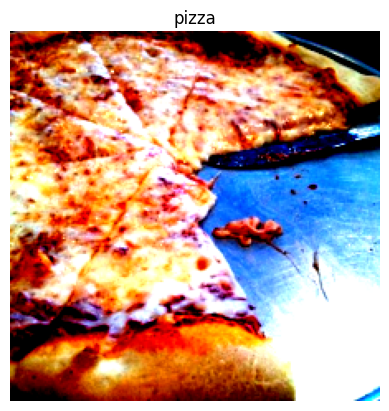

In [25]:
plt.imshow(res_train_dataloader.dataset[27][0].permute(1, 2, 0))
plt.title(class_names[res_train_dataloader.dataset[27][1]])
plt.axis(False)

In [44]:
# NEW: Setup the model with pretrained weights and send it to the target device (torchvision v0.13+)
resnet_model = torchvision.models.resnet50(weights=res_weights).to(device)

resnet_model

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\vo25aag/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 113MB/s] 


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
utils.save_model(model=resnet_model, model_name='ResNet-50.pth', target_dir='models')

[INFO] Saving model to: models\ResNet-50.pth


In [ ]:
summary(model=resnet_model,
        input_size=(32, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
        )

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
ResNet (ResNet)                          [32, 3, 224, 224]    [32, 1000]           --                   True
├─Conv2d (conv1)                         [32, 3, 224, 224]    [32, 64, 112, 112]   9,408                True
├─BatchNorm2d (bn1)                      [32, 64, 112, 112]   [32, 64, 112, 112]   128                  True
├─ReLU (relu)                            [32, 64, 112, 112]   [32, 64, 112, 112]   --                   --
├─MaxPool2d (maxpool)                    [32, 64, 112, 112]   [32, 64, 56, 56]     --                   --
├─Sequential (layer1)                    [32, 64, 56, 56]     [32, 256, 56, 56]    --                   True
│    └─Bottleneck (0)                    [32, 64, 56, 56]     [32, 256, 56, 56]    --                   True
│    │    └─Conv2d (conv1)               [32, 64, 56, 56]     [32, 64, 56, 56]     4,096                True
│    │    └─BatchN

## Transfer Learning on ResNet 50

In [ ]:
# Freeze all base layers in the "features" section of the model (the feature extractor) by setting requires_grad=False
for param in resnet_model.parameters():
    param.requires_grad = False

# Unfreeze the final classifier
for param in resnet_model.fc.parameters():
    param.requires_grad = True

Our output layer should match the num of classes we are predicting for

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

output_shape = len(class_names)

# Recreate the classifier layer and seed it to the target device
resnet_model.fc = torch.nn.Linear(resnet_model.fc.in_features, output_shape).to(device)

Recheck the model's summary to know if its classifier layer has been updated

In [ ]:
resnet_model.fc

Linear(in_features=2048, out_features=3, bias=True)

In [ ]:
summary(resnet_model,
        input_size=(32, 3, 224, 224),
        verbose=0,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
        )

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
ResNet (ResNet)                          [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Conv2d (conv1)                         [32, 3, 224, 224]    [32, 64, 112, 112]   (9,408)              False
├─BatchNorm2d (bn1)                      [32, 64, 112, 112]   [32, 64, 112, 112]   (128)                False
├─ReLU (relu)                            [32, 64, 112, 112]   [32, 64, 112, 112]   --                   --
├─MaxPool2d (maxpool)                    [32, 64, 112, 112]   [32, 64, 56, 56]     --                   --
├─Sequential (layer1)                    [32, 64, 56, 56]     [32, 256, 56, 56]    --                   False
│    └─Bottleneck (0)                    [32, 64, 56, 56]     [32, 256, 56, 56]    --                   False
│    │    └─Conv2d (conv1)               [32, 64, 56, 56]     [32, 64, 56, 56]     (4,096)              False
│    │    

In [45]:
# Define loss and optimizer
res_loss_fn = nn.CrossEntropyLoss()
res_optimizer = torch.optim.Adam(resnet_model.parameters(), lr=0.001)

Train

In [ ]:
# set seeds for randomness
set_seeds()

# Start the timer
res_start_time = timer()

# Setup training and save the results
res_results = engine.train(model=resnet_model,
                       train_dataloader=res_train_dataloader,
                       test_dataloader=res_test_dataloader,
                       optimizer=res_optimizer,
                       loss_fn=res_loss_fn,
                       epochs=25,
                       device=device)

# End the timer and print out how long it took
res_end_time = timer()
print(f"[INFO] Total training time: {res_end_time-res_start_time:.3f} seconds")

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0671 | train_acc: 0.3711 | test_loss: 0.9851 | test_acc: 0.7424
Epoch: 2 | train_loss: 0.8752 | train_acc: 0.7227 | test_loss: 0.8942 | test_acc: 0.7330
Epoch: 3 | train_loss: 0.7503 | train_acc: 0.8711 | test_loss: 0.8038 | test_acc: 0.8456
Epoch: 4 | train_loss: 0.6718 | train_acc: 0.9375 | test_loss: 0.7385 | test_acc: 0.8864
Epoch: 5 | train_loss: 0.5992 | train_acc: 0.8242 | test_loss: 0.7115 | test_acc: 0.8759
Epoch: 6 | train_loss: 0.5577 | train_acc: 0.8320 | test_loss: 0.6852 | test_acc: 0.9072
Epoch: 7 | train_loss: 0.4883 | train_acc: 0.9492 | test_loss: 0.6415 | test_acc: 0.8665
Epoch: 8 | train_loss: 0.4995 | train_acc: 0.8320 | test_loss: 0.6390 | test_acc: 0.8258
Epoch: 9 | train_loss: 0.4712 | train_acc: 0.8438 | test_loss: 0.6606 | test_acc: 0.8665
Epoch: 10 | train_loss: 0.3911 | train_acc: 0.9570 | test_loss: 0.5562 | test_acc: 0.9583
Epoch: 11 | train_loss: 0.4046 | train_acc: 0.9688 | test_loss: 0.6051 | test_acc: 0.9384
Epoch: 12 | train_l

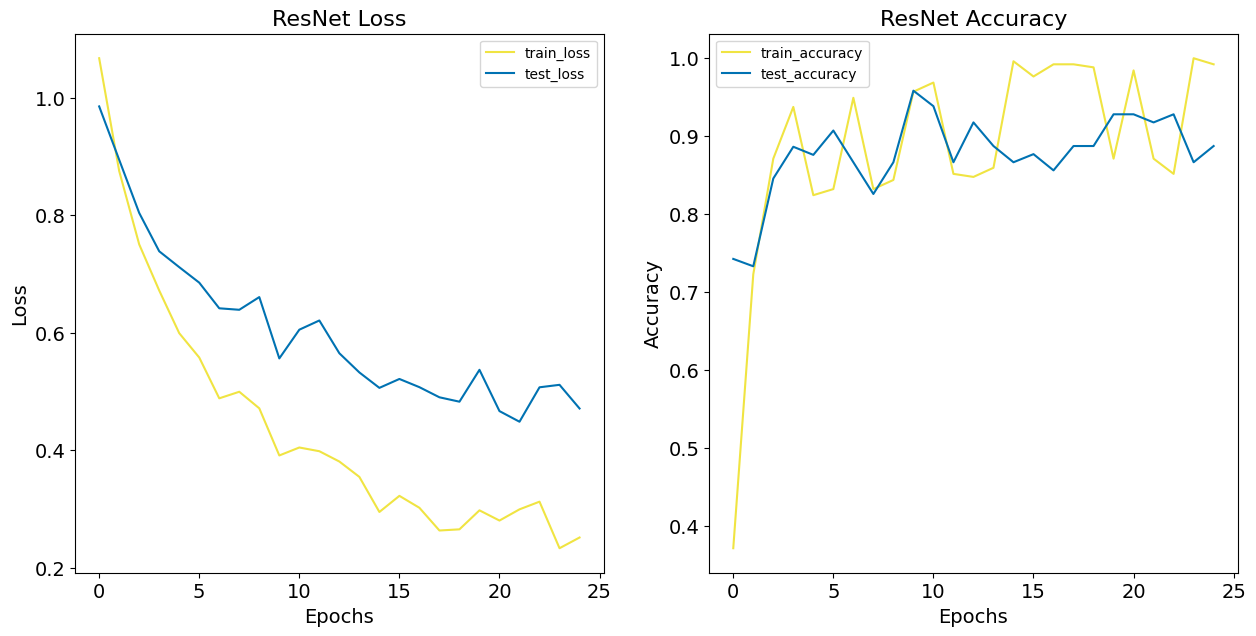

In [ ]:
plot_loss_curves(res_results, 'ResNet (225 imgs)', res_end_time-res_start_time)

# Vision Transformer (ViT)

In [50]:
pretrained_vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT
pretrained_vit = torchvision.models.vit_b_16(weights=pretrained_vit_weights).to(device)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to C:\Users\vo25aag/.cache\torch\hub\checkpoints\vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 117MB/s]  


In [51]:
pretrained_vit

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

Get the transforms used to create our pretrained weights

In [52]:
vit_auto_transforms = pretrained_vit_weights.transforms()

# Transfer learning for Vision Transformer

feeeze patching and embedding layers

In [53]:
for params in pretrained_vit.conv_proj.parameters():
    params.requires_grad = False

freeze encoder layers

In [54]:
for params in pretrained_vit.encoder.parameters():
    params.requires_grad = False

Edit the classifer head to match classes in our dataset and ensure it is trainable

In [55]:
pretrained_vit.heads = nn.Sequential(
    nn.Linear(in_features=768, out_features=3)
)

# View the modified model summary

In [56]:
summary(model=pretrained_vit,
        # (batch_size, num_patches, embedding_dimension)
        input_size=(1,3,224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [1, 3, 224, 224]     [1, 3]               768                  Partial
├─Conv2d (conv_proj)                                         [1, 3, 224, 224]     [1, 768, 14, 14]     (590,592)            False
├─Encoder (encoder)                                          [1, 197, 768]        [1, 197, 768]        151,296              False
│    └─Dropout (dropout)                                     [1, 197, 768]        [1, 197, 768]        --                   --
│    └─Sequential (layers)                                   [1, 197, 768]        [1, 197, 768]        --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [1, 197, 768]        [1, 197, 768]        (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [1, 197, 768]        [1, 1

split dataset into train and test set

In [57]:
BATCH_SIZE = 32

vit_train_dataloader, vit_test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir, test_dir=test_dir, transform=vit_auto_transforms, batch_size=BATCH_SIZE)

vit_train_dataloader, vit_test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x16abe13cf20>,
 ['pizza', 'steak', 'sushi'])

Train

In [ ]:
vit_optimizer = torch.optim.Adam(params=pretrained_vit.parameters(), lr=3e-3, betas=(0.9, 0.999), weight_decay=0.3)
vit_loss_fn = torch.nn.CrossEntropyLoss()

set_seeds()

# Start the timer
vit_start_time = timer()

vit_results = engine.train(model=pretrained_vit, train_dataloader=vit_train_dataloader, test_dataloader=vit_test_dataloader,
                       optimizer=vit_optimizer, loss_fn=vit_loss_fn, epochs=25, device=device)

# End the timer and print out how long it took
vit_end_time = timer()
print(f"[INFO] Total training time: {vit_end_time-vit_start_time:.3f} seconds")

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.4670 | train_acc: 0.8477 | test_loss: 0.2137 | test_acc: 0.9384
Epoch: 2 | train_loss: 0.1234 | train_acc: 0.9766 | test_loss: 0.1842 | test_acc: 0.9280
Epoch: 3 | train_loss: 0.0840 | train_acc: 0.9727 | test_loss: 0.2267 | test_acc: 0.8977
Epoch: 4 | train_loss: 0.0614 | train_acc: 0.9883 | test_loss: 0.2058 | test_acc: 0.9280
Epoch: 5 | train_loss: 0.0625 | train_acc: 0.9961 | test_loss: 0.2092 | test_acc: 0.9280
Epoch: 6 | train_loss: 0.0866 | train_acc: 0.9961 | test_loss: 0.2374 | test_acc: 0.9081
Epoch: 7 | train_loss: 0.0876 | train_acc: 0.9922 | test_loss: 0.2306 | test_acc: 0.9384
Epoch: 8 | train_loss: 0.0757 | train_acc: 0.9961 | test_loss: 0.2002 | test_acc: 0.9384
Epoch: 9 | train_loss: 0.1107 | train_acc: 0.9922 | test_loss: 0.2034 | test_acc: 0.9384
Epoch: 10 | train_loss: 0.1031 | train_acc: 0.9805 | test_loss: 0.2024 | test_acc: 0.9280
Epoch: 11 | train_loss: 0.0709 | train_acc: 0.9922 | test_loss: 0.2852 | test_acc: 0.8977
Epoch: 12 | train_l

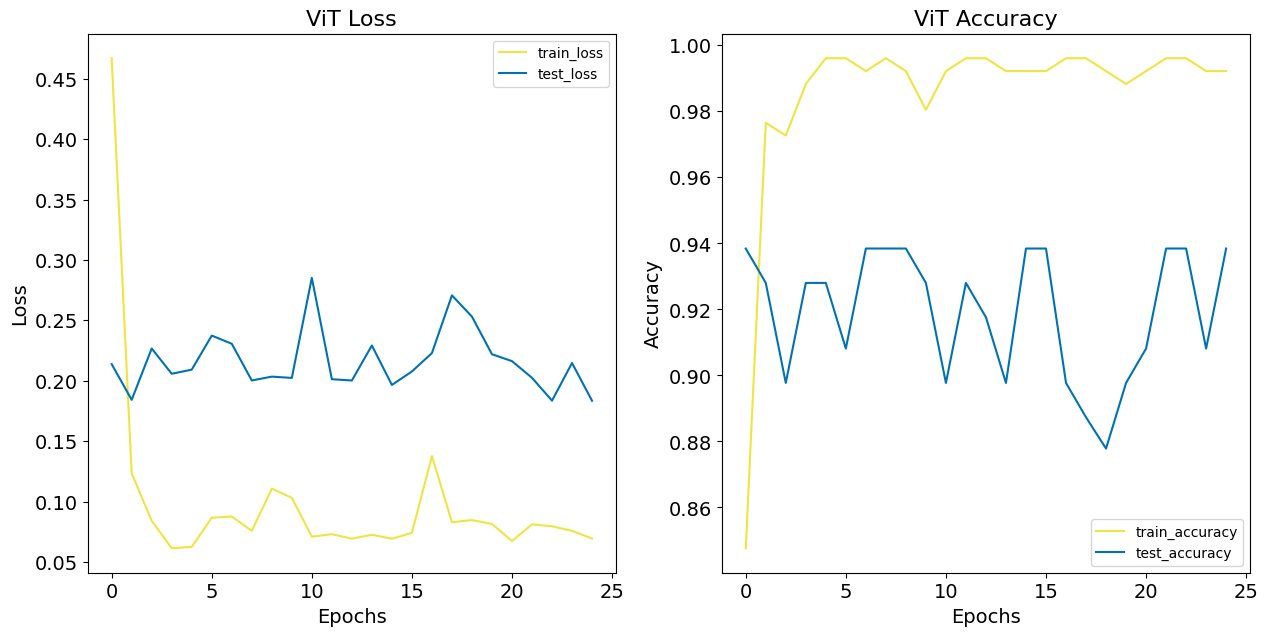

In [ ]:
plot_loss_curves(vit_results, 'ViT (225 imgs)', vit_end_time-vit_start_time)

## Pretraining both models on 20% of food 101 datasets (20200) images

### Get the dataset

In [ ]:
import requests
import tarfile
import os  # Import os module for file handling

# Step 1: Download the dataset
url = 'http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz'
response = requests.get(url)

# Save the downloaded file
with open('food-101.tar.gz', 'wb') as file:
    file.write(response.content)
print("Dataset downloaded successfully!")

# Step 2: Extract the tar.gz file
with tarfile.open('food-101.tar.gz', 'r:gz') as tar:
    tar.extractall(path='food-101')  # Extract to a folder named 'food-101'
print("Dataset extracted successfully!")

# Step 3: Delete the .tar.gz file
os.remove('food-101.tar.gz')
print("Downloaded .tar.gz file deleted successfully!")

Dataset downloaded successfully!


C:\Users\vo25aag\AppData\Local\Temp\ipykernel_10300\188837465.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='food-101')  # Extract to a folder named 'food-101'


Dataset extracted successfully!


### ResNet

#### Split the dataset into train and test splits and apply the resnet transforms

In [68]:
data_dir = Path("food-101")
if Path(data_dir / "food-101").exists() and Path("food-101/food-101/license_agreement.txt").is_file():
    res_full_train_data = datasets.Food101(
        root=data_dir, split="train", transform=res_auto_transforms, download=False)
    res_full_test_data = datasets.Food101(
        root=data_dir, split="test", transform=res_auto_transforms, download=False)
else:
    res_full_train_data = datasets.Food101(root=data_dir, split="train", transform=res_auto_transforms, download=True)

    res_full_test_data = datasets.Food101(root=data_dir, split="test", transform=res_auto_transforms, download=True)

Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "c:\Python312\Lib\multiprocessing\queues.py", line 259, in _feed
Exception ignored in: <function _ConnectionBase.__del__ at 0x00000168052E6B60>
Traceback (most recent call last):
  File "c:\Python312\Lib\multiprocessing\connection.py", line 133, in __del__
    reader_close()
  File "c:\Python312\Lib\multiprocessing\connection.py", line 178, in close
    self._close()
  File "c:\Python312\Lib\multiprocessing\connection.py", line 282, in _close
    self._close()
  File "c:\Python312\Lib\multiprocessing\connection.py", line 282, in _close
    _CloseHandle(self._handle)
OSError: [WinError 6] The handle is invalid
    _CloseHandle(self._handle)
OSError: [WinError 6] The handle is invalid

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Python312\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "c:\Python312\Lib\threading.p

#### Get only 20 pecent of the dataset

In [67]:

def split_dataset(dataset: torchvision.datasets, split_size: float=0.2, seed:int=42):
    length_1 = int(len(dataset) * split_size)
    length_2 = len(dataset) - length_1

    print(f"[INFO] Splitting dataset of length {len(dataset)} into splits of size {length_1} ({int(split_size*100)}%), {length_2} ({int((1-split_size)*100)}%)")

    random_split_1, random_split_2 = torch.utils.data.random_split(dataset, lengths=[length_1, length_2], generator=torch.manual_seed(seed))

    return random_split_1, random_split_2

In [69]:
res_train_data_food101_20_percent, _ = split_dataset(dataset=res_full_train_data,
                                                 split_size=0.2)

# Create testing 20% split of Food101
res_test_data_food101_20_percent, _ = split_dataset(dataset=res_full_test_data,
                                                split_size=0.2)

len(res_train_data_food101_20_percent), len(res_test_data_food101_20_percent)

[INFO] Splitting dataset of length 75750 into splits of size 15150 (20%), 60600 (80%)
[INFO] Splitting dataset of length 25250 into splits of size 5050 (20%), 20200 (80%)


(15150, 5050)

view the number of classes in the full dataset

In [70]:
food101_class_names = res_full_train_data.classes
print(food101_class_names[:10], end='\n\n')
print(len(food101_class_names))

['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']

101


In [71]:
res_train_data_food101_20_percent, res_test_data_food101_20_percent

(<torch.utils.data.dataset.Subset at 0x16bba37b9b0>,
 <torch.utils.data.dataset.Subset at 0x16bb7b97260>)

#### Data Preprocessing

In [72]:
# ensure to use every worker on our cpu for faster processing
NUM_WORKERS = os.cpu_count()

BATCH_SIZE = 32
res_train_dataloader_food101 = torch.utils.data.DataLoader(
    res_train_data_food101_20_percent, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
res_test_dataloader_food101 = torch.utils.data.DataLoader(
    res_test_data_food101_20_percent, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=False)

##### Training / Transfer Learning

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Start the timer
res2_start_time = timer()

# Setup training and save the results
res2_results = engine.train(model=resnet_model,
                       train_dataloader=res_train_dataloader_food101,
                       test_dataloader=res_test_dataloader_food101,
                       optimizer=res_optimizer,
                       loss_fn=res_loss_fn,
                       epochs=10,
                       device=device)

# End the timer and print out how long it took
res2_end_time = timer()
print(f"[INFO] Total training time: {res2_end_time-res2_start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1589 | train_acc: 0.6931 | test_loss: 1.2024 | test_acc: 0.6748
Epoch: 2 | train_loss: 0.6399 | train_acc: 0.8250 | test_loss: 1.2843 | test_acc: 0.6573
Epoch: 3 | train_loss: 0.3275 | train_acc: 0.9093 | test_loss: 1.3056 | test_acc: 0.6774
Epoch: 4 | train_loss: 0.2206 | train_acc: 0.9403 | test_loss: 1.3358 | test_acc: 0.6755
Epoch: 5 | train_loss: 0.1612 | train_acc: 0.9549 | test_loss: 1.5842 | test_acc: 0.6426
Epoch: 6 | train_loss: 0.1495 | train_acc: 0.9591 | test_loss: 1.4854 | test_acc: 0.6630
Epoch: 7 | train_loss: 0.1665 | train_acc: 0.9525 | test_loss: 1.6986 | test_acc: 0.6317
Epoch: 8 | train_loss: 0.1187 | train_acc: 0.9656 | test_loss: 1.6625 | test_acc: 0.6358
Epoch: 9 | train_loss: 0.1264 | train_acc: 0.9637 | test_loss: 1.6369 | test_acc: 0.6385
Epoch: 10 | train_loss: 0.0858 | train_acc: 0.9772 | test_loss: 1.5758 | test_acc: 0.6738
[INFO] Total training time: 2127.673 seconds


##### visualize the results

In [76]:
plot_loss_curves(res2_results, 'ResNet (20200 imgs)', res2_end_time-res2_start_time)

NameError: name 'res2_results' is not defined

### ViT
 #### Split the dataset into train and test splits and apply the ViT transforms

In [ ]:
data_dir = Path("food-101")
if Path(data_dir / "food-101").exists() and Path("food-101/food-101/license_agreement.txt").is_file():
    vit_full_train_data = datasets.Food101(
        root=data_dir, split="train", transform=vit_auto_transforms, download=False)
    vit_full_test_data = datasets.Food101(
        root=data_dir, split="test", transform=vit_auto_transforms, download=False)
else:
    vit_full_train_data = datasets.Food101(root=data_dir, split="train", transform=vit_auto_transforms, download=True)

    vit_full_test_data = datasets.Food101(root=data_dir, split="test", transform=vit_auto_transforms, download=True)

##### get only 20% of the dataset

In [ ]:
vit_train_data_food101_20_percent, _ = split_dataset(dataset=vit_full_train_data,
                                                 split_size=0.2)

# Create testing 20% split of Food101
vit_test_data_food101_20_percent, _ = split_dataset(dataset=vit_full_test_data,
                                                split_size=0.2)

len(vit_train_data_food101_20_percent), len(vit_test_data_food101_20_percent)

##### view

In [ ]:
food101_class_names = vit_full_train_data.classes
print(food101_class_names[:10], end='\n\n')
print(len(food101_class_names))

In [ ]:
vit_train_data_food101_20_percent, vit_test_data_food101_20_percent

#### Data Preprocessing

In [ ]:
BATCH_SIZE = 32
vit_train_dataloader_food101 = torch.utils.data.DataLoader(
    vit_train_data_food101_20_percent, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
vit_test_dataloader_food101 = torch.utils.data.DataLoader(
    vit_test_data_food101_20_percent, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=False)

In [ ]:
set_seeds()

# Start the timer
vit2_start_time = timer()

# Setup training and save the results
vit2_results = engine.train(model=pretrained_vit,
                       train_dataloader=vit_train_dataloader_food101,
                       test_dataloader=vit_test_dataloader_food101,
                       optimizer=vit_optimizer,
                       loss_fn=vit_loss_fn,
                       epochs=10,
                       device=device)

# End the timer and print out how long it took
vit2_end_time = timer()
print(f"[INFO] Total training time: {vit2_end_time-vit2_start_time:.3f} seconds")

##### visualize the training result

In [ ]:

plot_loss_curves(vit2_results, 'ViT (20200 imgs)', vit2_end_time-vit2_start_time)